In [45]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 14

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [46]:
# define the file name
filename = "baseline2-250cm" 
""
# import file to jupyter notebook
df = readfile("./" + filename + ".csv")
# check the imported data first 10 lines
df.head(10)

,index,time_rx,rssi,seq,payload
0,0,2026-04-15 13:51:42.412,-93,137,2a 6c 26 bd 1e a6 21 2b 17 29 17 40 29 c6
1,1,2026-04-15 13:51:42.678,-91,138,aa 5a 23 15 56 16 5a 57 25 c2 1d 8e 23 4c 6b 7...
2,2,2026-04-15 13:51:42.916,-93,139,2a 94 1a 5e 1e 55 2a 91 48 a0 24 75 24 c5
3,3,2026-04-15 13:51:43.957,-92,143,2a b4 26 50 26 96 21 42 18 59 2c 9d 26 ff
4,4,2026-04-15 13:51:44.226,-91,144,2a c0 2f 77 2b b7 1c 4c 1c 0d 22 2c 24 09
5,5,2026-04-15 13:51:44.478,-93,145,2a cc 14 dc 22 1f 28 a0 1f 24 18 1e 16 cc
6,6,2026-04-15 13:51:45.002,-79,95,2a e4 1c a8 26 f1 69 b5 29 4a 2a
7,7,2026-04-15 13:51:56.279,-89,0,00 00 13 5d 1f 43 1b 45 25 6f 21 fe 0f 7e
8,8,2026-04-15 13:51:56.549,-91,1,00 0c 20 6b 2b b0 24 4b 26 55 1a 56 22 e8
9,9,2026-04-15 13:51:57.324,-95,4,00 30 1c 08 23 fc 17 c2 22 1b 1c e4 25 de


In [47]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [48]:
# compute the file delay
file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
# convert the timedelta to s
file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is : 0 days 00:01:35.007000, which is 95.007 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [49]:
# compute the BER for all received packets
# return the in total ber for received file, error statistics and correct file content supposed to be transmitted
ber = compute_ber(test, PACKET_LEN=NUM_16RND*2)
bit_reliability = (1-ber)*100
print(f"Bit error rate [%]: {(ber*100):.8f}\t\t(in received packets within pseudo sequence + payload) ")
if len(df) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    print(f"Data rate [bit/s]: {(len(df)*NUM_16RND*2/file_delay_s):.8f}\t\t(directly impacted by missed packets) ")

The total number of packets transmitted by the tag is 58.
Bit error rate [%]: 6.84189406		(in received packets within pseudo sequence + payload) 
Data rate [bit/s]: 25.13499005		(directly impacted by missed packets) 


In [50]:
# def is_valid_packet(pkt):
#     return getattr(pkt, "has_sync", False) and len(getattr(pkt, "bits", [])) == 16

# SENT = 200

# received = len(df)
# valid = sum(1 for pkt in df if is_valid_packet(pkt))

# lost = max(0, SENT - received)
# corrupted = max(0, received - valid)

# per = (lost + corrupted) / SENT if SENT > 0 else 0

# print(f"Packet Error Rate [%]: {per*100:.6f}")
# print(f"Lost packets: {lost}")
# print(f"Corrupted packets: {corrupted}")

In [51]:
rssi_values = df["rssi"].dropna()

if len(rssi_values) > 0:
    avg_rssi = rssi_values.mean()
    print(f"Average RSSI [dBm]: {avg_rssi:.2f}")
    print(f"Min RSSI: {rssi_values.min():.2f}")
    print(f"Max RSSI: {rssi_values.max():.2f}")
else:
    print("No RSSI data available.")

Average RSSI [dBm]: -91.62
Min RSSI: -103.00
Max RSSI: -70.00


In [52]:
SENT = 200
received = len(df)

pdr = received / SENT if SENT > 0 else 0

print(f"Packet Delivery Ratio [%]: {pdr*100:.6f}")

Packet Delivery Ratio [%]: 99.500000


In [53]:
# BER for each packet
print("Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.")
plt.scatter(range(len(df)), [compute_ber_packet(row,PACKET_LEN=NUM_16RND*2)[0] for (_,row) in df.iterrows()], marker='o', s=6, color='black')
plt.grid()
plt.ylabel('Bit Error Rate [%] (payload only / without seq-number and pseudo-seq-number)', fontsize=16)
plt.xlabel('Seq. Number', fontsize=16)

Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.


IndexError: list index out of range

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [ ]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[np.float64(407.213), 85.30783582089552, 16]


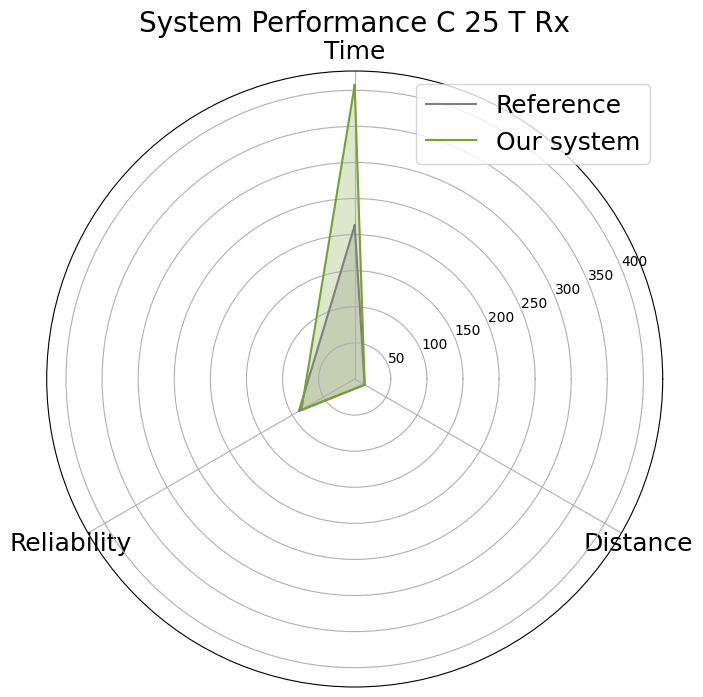

In [ ]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)